# Classificação Homer vs Bart — Rede Neural (sem Convolução)

---

**Integrantes do Grupo:**

| Nome | E-mail |
|------|--------|
| Nathália Rayanne Lima Araújo| nrla@cesar.school|

**Dataset:** [Neural Networks Homer and Bart Classification — Kaggle](https://www.kaggle.com/datasets/juniorbueno/neural-networks-homer-and-bart-classification)

**Objetivo:** Classificação binária de imagens de Homer e Bart Simpson usando uma rede neural **MLP (Multi-Layer Perceptron)**, sem camadas convolucionais, com PyTorch, seguindo a estrutura do notebook de referência `4.6-MNIST_neuralnet.ipynb`.

---
## 1. Importação das Bibliotecas

In [ ]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
print(f'PyTorch: {torch.__version__}')

Dispositivo: cpu
PyTorch: 2.11.0+cpu


---
## 2. Carregamento e Preparação do Dataset

### 2.1 Organização das pastas

In [ ]:
ORIGEM       = '/content/drive/MyDrive/Colab Notebooks/homer_bart_1'
DATASET_ROOT = '/content/drive/MyDrive/dataset'

DESTINOS = {
    'homer': {'train': os.path.join(DATASET_ROOT, 'train', 'homer'),
              'test':  os.path.join(DATASET_ROOT, 'test',  'homer')},
    'bart':  {'train': os.path.join(DATASET_ROOT, 'train', 'bart'),
              'test':  os.path.join(DATASET_ROOT, 'test',  'bart')},
}

for cls_dirs in DESTINOS.values():
    for p in cls_dirs.values():
        os.makedirs(p, exist_ok=True)

def organizar_dataset(origem, destinos, ratio_treino=0.8):
    """Separa imagens em treino/teste mantendo proporção por classe."""
    arquivos = sorted(os.listdir(origem))
    for cls in ['homer', 'bart']:
        imgs = [f for f in arquivos if f.lower().startswith(cls)
                and f.lower().endswith(('.jpg', '.jpeg', '.png','.bmp'))]
        corte = int(len(imgs) * ratio_treino)
        for f in imgs[:corte]:
            dst = os.path.join(destinos[cls]['train'], f)
            if not os.path.exists(dst):
                shutil.copy(os.path.join(origem, f), dst)
        for f in imgs[corte:]:
            dst = os.path.join(destinos[cls]['test'], f)
            if not os.path.exists(dst):
                shutil.copy(os.path.join(origem, f), dst)

if os.path.exists(ORIGEM):
    organizar_dataset(ORIGEM, DESTINOS)

# Contagem
for split in ['train', 'test']:
    for cls in ['homer', 'bart']:
        p = DESTINOS[cls][split]
        n = len(os.listdir(p)) if os.path.exists(p) else 0
        print(f'{cls.capitalize()} {split:5s}: {n} imagens')

Homer train: 87 imagens
Bart train: 128 imagens
Homer test : 22 imagens
Bart test : 32 imagens


### 2.2 Análise Exploratória (EDA)

Visualizamos a distribuição de classes e amostras do dataset antes de qualquer pré-processamento.


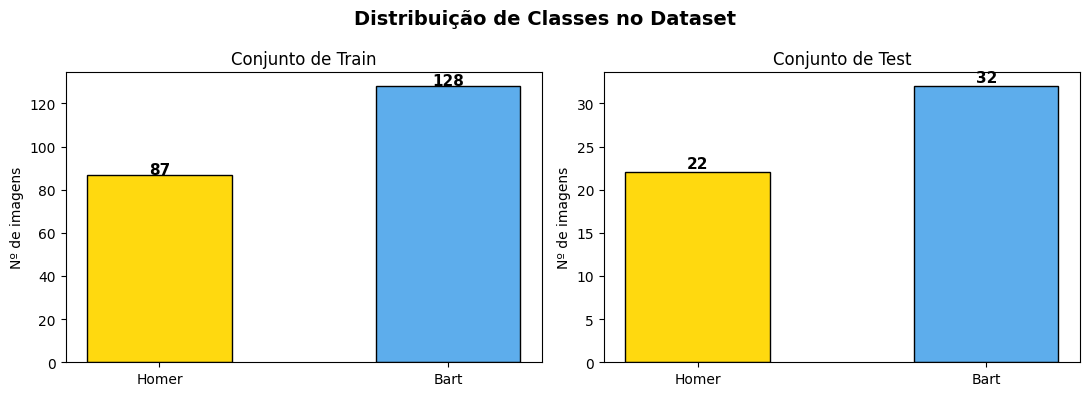

Total treino: 215 | Total teste: 54


In [ ]:
contagens = {}
for split in ['train', 'test']:
    for cls in ['homer', 'bart']:
        p = DESTINOS[cls][split]
        contagens[f'{cls}_{split}'] = len(os.listdir(p)) if os.path.exists(p) else 0

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Distribuição de Classes no Dataset', fontsize=14, fontweight='bold')

for ax, split, cor in zip(axes, ['train', 'test'], [['#FFD90F', '#5DADEC'], ['#FFD90F', '#5DADEC']]):
    vals  = [contagens[f'homer_{split}'], contagens[f'bart_{split}']]
    bars  = ax.bar(['Homer', 'Bart'], vals, color=cor, edgecolor='black', width=0.5)
    ax.set_title(f'Conjunto de {split.capitalize()}', fontsize=12)
    ax.set_ylabel('Nº de imagens')
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                str(int(b.get_height())), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_distribuicao.png', dpi=120, bbox_inches='tight')
plt.show()

total_treino = contagens['homer_train'] + contagens['bart_train']
total_teste  = contagens['homer_test']  + contagens['bart_test']
print(f'Total treino: {total_treino} | Total teste: {total_teste}')

---
## 3. Pré-processamento e DataLoaders

Como a rede é um **MLP (sem convolução)**, a imagem precisa ser convertida em vetor 1D.
Usamos **64×64 × 3 canais RGB = 12.288** features de entrada.

- **Treino:** resize + data augmentation (flip, rotação, colorjitter) + normalização
- **Validação / Teste:** apenas resize + normalização (sem augmentation)

A divisão de validação (20% do treino) usa os **mesmos índices aleatórios** mas instâncias
diferentes do Dataset, garantindo que cada split receba a transformação correta.

### 2.1 Transformações e Data Augmentation

In [ ]:
IMG_SIZE  = 64
IMG_MEAN  = [0.5, 0.5, 0.5]
IMG_STD   = [0.5, 0.5, 0.5]
INPUT_DIM = IMG_SIZE * IMG_SIZE * 3

# Transformações
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMG_MEAN, std=IMG_STD),])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMG_MEAN, std=IMG_STD),])

# Dataset customizado
class HomerBartDataset(Dataset):
    CLASS_TO_IDX = {'homer': 0, 'bart': 1}

    def __init__(self, root_dir: str, transform=None):
        self.transform = transform
        self.samples   = []
        for cls, idx in self.CLASS_TO_IDX.items():
            cls_dir = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):  # ← fix
                    self.samples.append((os.path.join(cls_dir, fname), idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

# Carrega splits
train_dir = os.path.join(DATASET_ROOT, 'train')
test_dir  = os.path.join(DATASET_ROOT, 'test')

full_train_ds = HomerBartDataset(train_dir, transform=train_transform)
full_val_ds   = HomerBartDataset(train_dir, transform=eval_transform)
test_ds       = HomerBartDataset(test_dir,  transform=eval_transform)

n_total   = len(full_train_ds)
n_val     = int(0.2 * n_total)
n_train   = n_total - n_val

gen     = torch.Generator().manual_seed(SEED)
indices = torch.randperm(n_total, generator=gen).tolist()

train_ds = Subset(full_train_ds, indices[:n_train])
val_ds   = Subset(full_val_ds,   indices[n_train:])

# DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Treino: {len(train_ds)} | Validação: {len(val_ds)} | Teste: {len(test_ds)}')
print(f'Batches por época (treino): {len(train_loader)}')
print(f'Shape de um batch: {next(iter(train_loader))[0].shape}')


Treino: 172 | Validação: 43 | Teste: 54
Batches por época (treino): 6


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Shape de um batch: torch.Size([32, 3, 64, 64])


### 3.1 Amostras do Conjunto de Treino

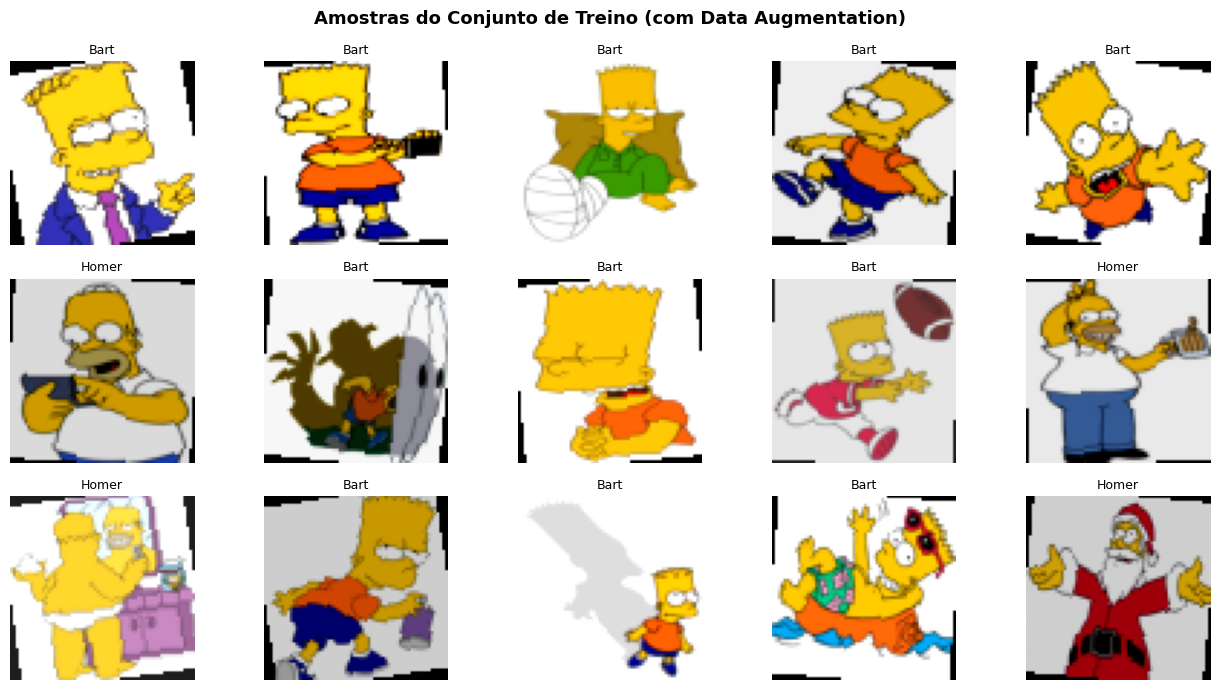

In [ ]:
LABEL_NAMES = {0: 'Homer', 1: 'Bart'}

def imshow(tensor, title=None, ax=None):
    """Desnormaliza e exibe tensor de imagem (C, H, W)."""
    img = tensor.numpy().transpose((1, 2, 0))
    img = np.clip(img * 0.5 + 0.5, 0, 1)
    target_ax = ax if ax is not None else plt.gca()
    target_ax.imshow(img)
    if title:
        target_ax.set_title(title, fontsize=9)
    target_ax.axis('off')

imgs, labels = next(iter(train_loader))

fig, axes = plt.subplots(3, 5, figsize=(13, 7))
fig.suptitle('Amostras do Conjunto de Treino (com Data Augmentation)', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    imshow(imgs[i], title=LABEL_NAMES[labels[i].item()], ax=ax)

plt.tight_layout()
plt.savefig('amostras_treino.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4. Definição do Modelo — MLP

Rede MLP totalmente conectada, **sem camadas convolucionais**, seguindo a estrutura do notebook MNIST de referência.

| Camada | Entrada | Saída | Após |
|--------|---------|-------|------|
| fc1 | 12.288 | 2.048 | BN → ReLU → Dropout(0.5) |
| fc2 | 2.048 | 512 | BN → ReLU → Dropout(0.4) |
| fc3 | 512 | 128 | BN → ReLU → Dropout(0.3) |
| fc_out | 128 | 2 | LogSoftmax |

**Batch Normalization** estabiliza o treino; **Dropout** previne overfitting; **LogSoftmax + NLLLoss** é equivalente ao CrossEntropyLoss, seguindo o padrão do notebook de referência.


In [ ]:
class HomerBartMLP(nn.Module):
    """MLP totalmente conectado — classificação binária Homer vs Bart."""

    def __init__(self, input_dim: int = INPUT_DIM):
        super(HomerBartMLP, self).__init__()

        self.fc1   = nn.Linear(input_dim, 2048)
        self.bn1   = nn.BatchNorm1d(2048)
        self.drop1 = nn.Dropout(0.5)

        self.fc2   = nn.Linear(2048, 512)
        self.bn2   = nn.BatchNorm1d(512)
        self.drop2 = nn.Dropout(0.4)

        self.fc3   = nn.Linear(512, 128)
        self.bn3   = nn.BatchNorm1d(128)
        self.drop3 = nn.Dropout(0.3)

        self.fc_out = nn.Linear(128, 2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.flatten(x, start_dim=1)
        x = self.drop1(F.relu(self.bn1(self.fc1(x))))
        x = self.drop2(F.relu(self.bn2(self.fc2(x))))
        x = self.drop3(F.relu(self.bn3(self.fc3(x))))
        return F.log_softmax(self.fc_out(x), dim=1)


model = HomerBartMLP(input_dim=INPUT_DIM).to(device)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f'\nTotal de parâmetros:     {total_params:,}')
print(f'Parâmetros treináveis:   {trainable_params:,}')
print(f'Dispositivo:             {device}')

HomerBartMLP(
  (fc1): Linear(in_features=12288, out_features=2048, bias=True)
  (bn1): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=2048, out_features=512, bias=True)
  (bn2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop2): Dropout(p=0.4, inplace=False)
  (fc3): Linear(in_features=512, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop3): Dropout(p=0.3, inplace=False)
  (fc_out): Linear(in_features=128, out_features=2, bias=True)
)

Total de parâmetros:     26,288,258
Parâmetros treináveis:   26,288,258
Dispositivo:             cpu


---
## 5. Funções de Treinamento e Avaliação

Seguindo exatamente a estrutura do notebook `4.6-MNIST_neuralnet.ipynb` de referência:
- `train_epoch`: executa um passo de treino por batch e loga progresso
- `evaluate`: avalia o modelo em modo `eval()` sem gradiente e retorna perda e acurácia


In [ ]:
def train_epoch(model, device, loader, optimizer, epoch, log_interval=10):
    """Executa uma época de treinamento — retorna (perda_média, acurácia)."""
    model.train()
    total_loss    = 0.0
    correct       = 0
    total_samples = 0

    for batch_idx, (data, target) in enumerate(loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss   = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()

        total_loss    += loss.item() * data.size(0)
        correct       += output.argmax(dim=1).eq(target).sum().item()
        total_samples += data.size(0)

        if batch_idx % log_interval == 0:
            print(
                f'  Época {epoch} [{batch_idx * len(data)}/{len(loader.dataset)} '
                f'({100. * batch_idx / len(loader):.0f}%)]  '
                f'Perda: {loss.item():.6f}'
            )

    return total_loss / total_samples, 100. * correct / total_samples


def evaluate(model, device, loader):
    """Avalia o modelo — retorna (perda_média, acurácia)."""
    model.eval()
    eval_loss = 0.0
    correct   = 0

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output     = model(data)
            eval_loss += F.nll_loss(output, target, reduction='sum').item()
            pred       = output.argmax(dim=1, keepdim=True)
            correct   += pred.eq(target.view_as(pred)).sum().item()

    eval_loss /= len(loader.dataset)
    accuracy   = 100. * correct / len(loader.dataset)
    return eval_loss, accuracy

---
## 6. Treinamento

**Hiperparâmetros:**
- Otimizador: Adam (lr=1e-3, weight_decay=1e-4)
- Scheduler: StepLR reduz a LR em 50% a cada 10 épocas
- 40 épocas com salvamento do melhor modelo por acurácia de validação


In [ ]:
EPOCHS          = 40
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
LR_STEP         = 10
LR_GAMMA        = 0.5
BEST_MODEL_PATH = 'homer_bart_best.pt'

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

print('TREINAMENTO:')
for epoch in range(1, EPOCHS + 1):
    print(f'\n--- Época {epoch}/{EPOCHS} ---')

    t_loss, t_acc = train_epoch(model, device, train_loader, optimizer, epoch)
    v_loss, v_acc = evaluate(model, device, val_loader)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    print(f'  Treino    — Perda: {t_loss:.4f}  Acurácia: {t_acc:.2f}%')
    print(f'  Validação — Perda: {v_loss:.4f}  Acurácia: {v_acc:.2f}%')

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'  ✓ Melhor modelo salvo! Val Acc = {best_val_acc:.2f}%')
    scheduler.step()
print(f'Treinamento concluído. Melhor Val Acc: {best_val_acc:.2f}%')

TREINAMENTO:

--- Época 1/40 ---
  Época 1 [0/172 (0%)]  Perda: 0.706622
  Treino    — Perda: 0.6740  Acurácia: 58.72%
  Validação — Perda: 0.5042  Acurácia: 83.72%
  ✓ Melhor modelo salvo! Val Acc = 83.72%

--- Época 2/40 ---
  Época 2 [0/172 (0%)]  Perda: 0.656270
  Treino    — Perda: 0.5818  Acurácia: 69.19%
  Validação — Perda: 0.6909  Acurácia: 74.42%

--- Época 3/40 ---
  Época 3 [0/172 (0%)]  Perda: 0.466191
  Treino    — Perda: 0.5153  Acurácia: 75.58%
  Validação — Perda: 1.0507  Acurácia: 62.79%

--- Época 4/40 ---
  Época 4 [0/172 (0%)]  Perda: 0.445107
  Treino    — Perda: 0.4813  Acurácia: 75.00%
  Validação — Perda: 0.6797  Acurácia: 65.12%

--- Época 5/40 ---
  Época 5 [0/172 (0%)]  Perda: 0.360941
  Treino    — Perda: 0.4528  Acurácia: 77.91%
  Validação — Perda: 0.5278  Acurácia: 76.74%

--- Época 6/40 ---
  Época 6 [0/172 (0%)]  Perda: 0.371712
  Treino    — Perda: 0.4381  Acurácia: 80.23%
  Validação — Perda: 0.4743  Acurácia: 79.07%

--- Época 7/40 ---
  Época 7 [0/

---
## 7. Análise de Performance

### 7.1 Curvas de Perda e Acurácia

As curvas abaixo são o principal diagnóstico de **overfitting** ou **underfitting**:
- Curva de treino muito abaixo da validação → **overfitting**
- Ambas altas e próximas → bom ajuste

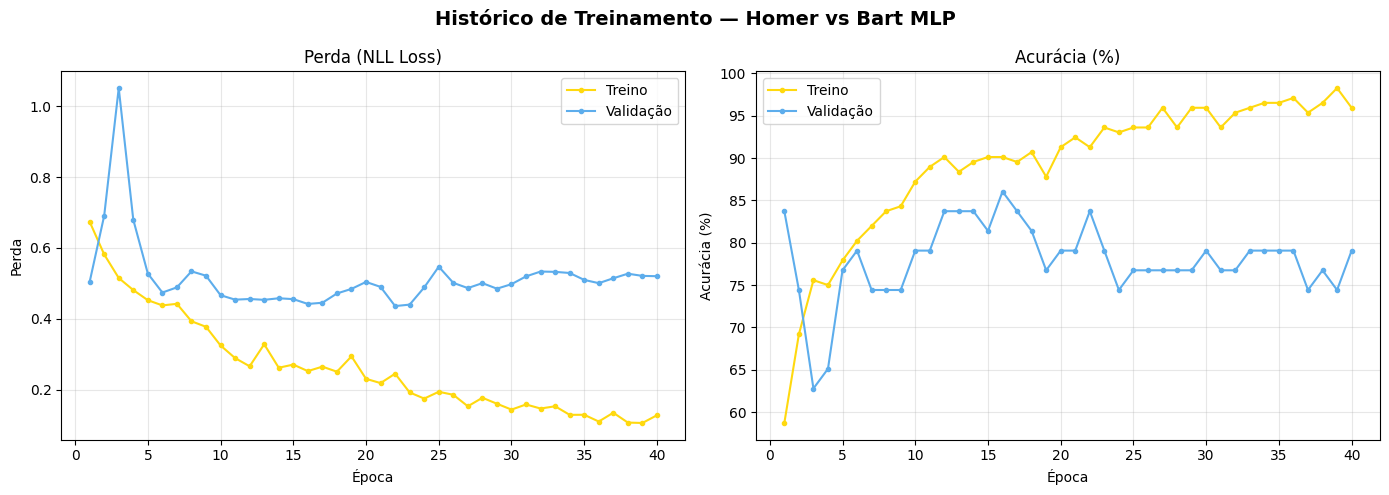

Melhor Val Acc: 86.05% (época 16)


In [ ]:
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Histórico de Treinamento — Homer vs Bart MLP', fontsize=14, fontweight='bold')

ax1.plot(epochs_range, history['train_loss'], '-o', markersize=3, color='#FFD90F', label='Treino')
ax1.plot(epochs_range, history['val_loss'],   '-o', markersize=3, color='#5DADEC', label='Validação')
ax1.set_title('Perda (NLL Loss)')
ax1.set_xlabel('Época')
ax1.set_ylabel('Perda')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs_range, history['train_acc'], '-o', markersize=3, color='#FFD90F', label='Treino')
ax2.plot(epochs_range, history['val_acc'],   '-o', markersize=3, color='#5DADEC', label='Validação')
ax2.set_title('Acurácia (%)')
ax2.set_xlabel('Época')
ax2.set_ylabel('Acurácia (%)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_treinamento.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Melhor Val Acc: {best_val_acc:.2f}% (época {int(np.argmax(history["val_acc"])) + 1})')

### 7.2 Métricas no Conjunto de Teste

Carregamos o **melhor modelo** salvo durante o treinamento (maior acurácia de validação)
e avaliamos sobre o conjunto de teste, que o modelo **nunca viu** durante o treino.


In [ ]:
# Carrega o melhor checkpoint
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for data, target in test_loader:
        data   = data.to(device)
        output = model(data)
        probs  = torch.exp(output).cpu()
        preds  = output.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(target.numpy())
        all_probs.extend(probs[:, 1].numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

acc  = accuracy_score(all_labels, all_preds)                          * 100
prec = precision_score(all_labels, all_preds, average='weighted')     * 100
rec  = recall_score(all_labels, all_preds, average='weighted')        * 100
f1   = f1_score(all_labels, all_preds, average='weighted')            * 100

print('MÉTRICAS DO CONJUNTO DE TESTE:')
print(f'  Acurácia  : {acc:.2f}%')
print(f'  Precisão  : {prec:.2f}%')
print(f'  Recall    : {rec:.2f}%')
print(f'  F1-Score  : {f1:.2f}%')
print()
print('Relatório por Classe:')
print(classification_report(all_labels, all_preds,
                             target_names=['Homer', 'Bart'], digits=4))

MÉTRICAS DO CONJUNTO DE TESTE:
  Acurácia  : 77.78%
  Precisão  : 77.61%
  Recall    : 77.78%
  F1-Score  : 77.59%

Relatório por Classe:
              precision    recall  f1-score   support

       Homer     0.7500    0.6818    0.7143        22
        Bart     0.7941    0.8438    0.8182        32

    accuracy                         0.7778        54
   macro avg     0.7721    0.7628    0.7662        54
weighted avg     0.7761    0.7778    0.7759        54



### 7.3 Matriz de Confusão

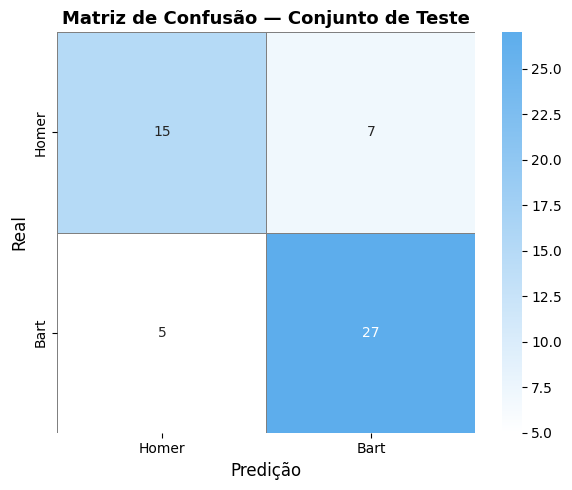

Verdadeiros Positivos (Bart correto) : 27
Verdadeiros Negativos (Homer correto): 15
Falsos Positivos                     : 7
Falsos Negativos                     : 5


In [ ]:
from matplotlib.colors import LinearSegmentedColormap

simpsons_blue = LinearSegmentedColormap.from_list('simpsons_blue', ['#FFFFFF', '#5DADEC'])

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap=simpsons_blue,
    xticklabels=['Homer', 'Bart'],
    yticklabels=['Homer', 'Bart'],
    ax=ax, linewidths=0.5, linecolor='gray')
ax.set_xlabel('Predição', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Matriz de Confusão — Conjunto de Teste', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Verdadeiros Positivos (Bart correto) : {tp}')
print(f'Verdadeiros Negativos (Homer correto): {tn}')
print(f'Falsos Positivos                     : {fp}')
print(f'Falsos Negativos                     : {fn}')

### 7.4 Curva ROC

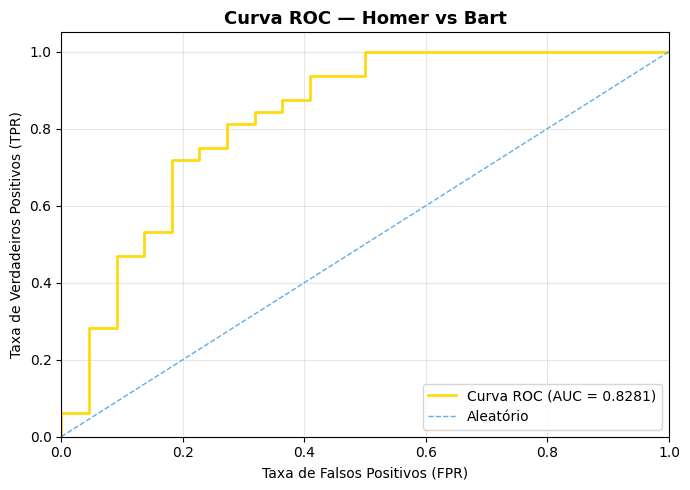

AUC-ROC: 0.8281


In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#FFD90F', lw=2,
         label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='#5DADEC', lw=1, linestyle='--', label='Aleatório')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC — Homer vs Bart', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'AUC-ROC: {roc_auc:.4f}')

### 7.5 Exemplos de Predição (Acertos e Erros)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


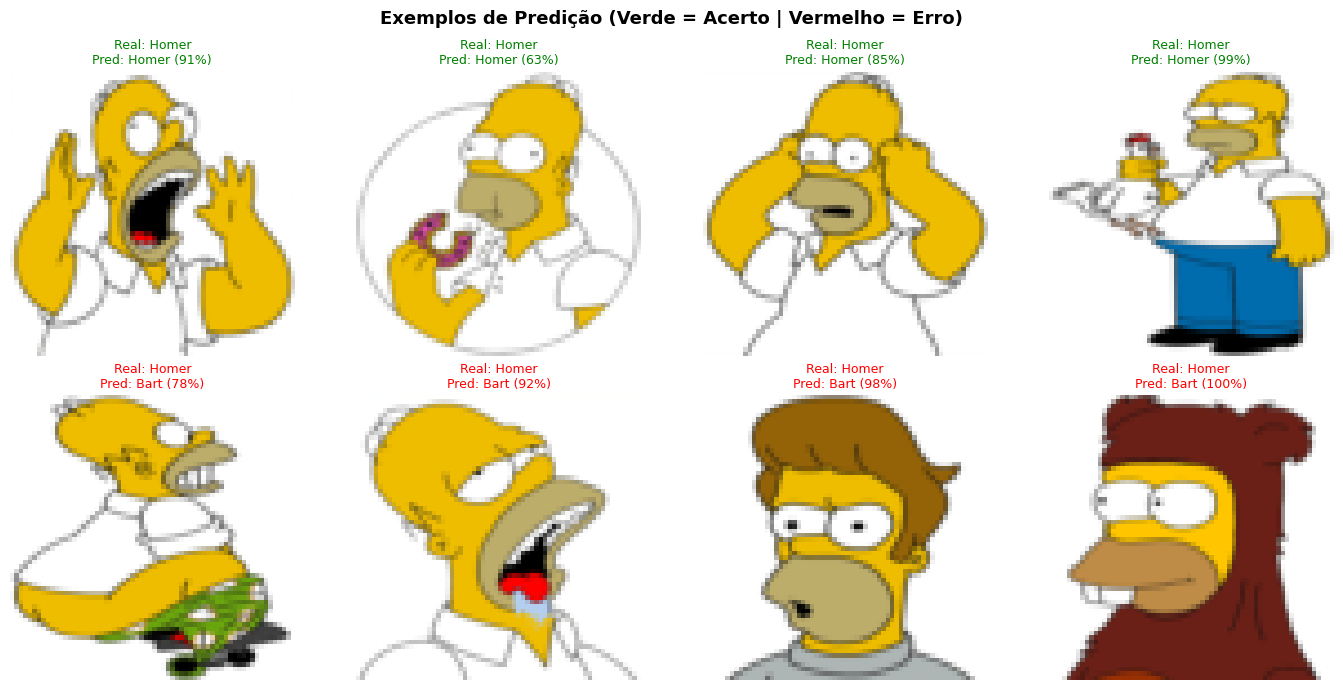

In [ ]:
correct_samples, wrong_samples = [], []

model.eval()
with torch.no_grad():
    for data, target in test_loader:
        output = model(data.to(device))
        probs  = torch.exp(output).cpu()
        preds  = output.argmax(dim=1).cpu()
        for i in range(len(target)):
            conf  = probs[i][preds[i].item()].item()
            entry = (data[i], target[i].item(), preds[i].item(), conf)
            if preds[i] == target[i] and len(correct_samples) < 4:
                correct_samples.append(entry)
            elif preds[i] != target[i] and len(wrong_samples) < 4:
                wrong_samples.append(entry)
        if len(correct_samples) >= 4 and len(wrong_samples) >= 4:
            break

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Exemplos de Predição (Verde = Acerto | Vermelho = Erro)',
             fontsize=13, fontweight='bold')

for i, (img, real, pred, conf) in enumerate(correct_samples):
    ax = axes[0, i]
    imshow(img, ax=ax)
    ax.set_title(f'Real: {LABEL_NAMES[real]}\nPred: {LABEL_NAMES[pred]} ({conf:.0%})',
                 color='green', fontsize=9)

for i, (img, real, pred, conf) in enumerate(wrong_samples):
    ax = axes[1, i]
    imshow(img, ax=ax)
    ax.set_title(f'Real: {LABEL_NAMES[real]}\nPred: {LABEL_NAMES[pred]} ({conf:.0%})',
                 color='red', fontsize=9)

axes[0, 0].set_ylabel('Acertos', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Erros',   fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('exemplos_predicao.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.6 Resumo Final

In [ ]:
print(f'  Arquitetura  : MLP ({INPUT_DIM}→2048→512→128→2)')
print(f'  Parâmetros   : {trainable_params:,}')
print(f'  Épocas       : {EPOCHS}')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  Otimizador   : Adam (lr={LR}, wd={WEIGHT_DECAY})')
print(f'  Scheduler    : StepLR (step={LR_STEP}, gamma={LR_GAMMA})')
print(f'  Melhor Val Acc   : {best_val_acc:.2f}%')
print(f'  Test Accuracy    : {acc:.2f}%')
print(f'  Test F1-Score    : {f1:.2f}%')
print(f'  AUC-ROC          : {roc_auc:.4f}')

  Arquitetura  : MLP (12288→2048→512→128→2)
  Parâmetros   : 26,288,258
  Épocas       : 40
  Batch size   : 32
  Otimizador   : Adam (lr=0.001, wd=0.0001)
  Scheduler    : StepLR (step=10, gamma=0.5)
  Melhor Val Acc   : 86.05%
  Test Accuracy    : 77.78%
  Test F1-Score    : 77.59%
  AUC-ROC          : 0.8281
